## **PMA-AI BOOTCAMP COHORT 9 — ASSESSMENT 2**
## **Applicant: Zona Zubair  |  Role: Fullstack + Data Science**
## **Dataset: Global Weather Repository (Kaggle)**
## **Tool: Google Colab**



# 🌍 Global Weather Analysis & Forecasting
# About PM Accelerator
## 1.    PM Accelerator's mission is to empower aspiring and experienced product managers through immersive, real-world training.
## 2.   We bridge the gap between theory and practice:
*  by providing mentorship, hands-on projects, and community-driven learning
*  helping members land top product roles and grow as leaders in tech.



## 1. Setup & Installation


In [ ]:
!pip install prophet plotly --quiet

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from prophet import Prophet

from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)

print("✅ All libraries imported.")

✅ All libraries imported.


## 2. Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/Data Science Assessment/GlobalWeatherRepository.csv'

In [ ]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)

Shape: 134,878 rows × 41 columns


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55


## 3. Data Cleaning & Preprocessing
Steps: parse dates → handle missing values → cap outliers → remove duplicates.

In [ ]:
# Parse date column
df['last_updated'] = pd.to_datetime(df['last_updated'], errors='coerce')
df = df.dropna(subset=['last_updated'])
df = df.sort_values('last_updated').reset_index(drop=True)

# Extract time components for grouping later
df['date']       = df['last_updated'].dt.date
df['year']       = df['last_updated'].dt.year
df['month']      = df['last_updated'].dt.month
df['month_name'] = df['last_updated'].dt.strftime('%b')
df['hour']       = df['last_updated'].dt.hour

print(f"Date range: {df['last_updated'].min().date()} → {df['last_updated'].max().date()}")

Date range: 2024-05-16 → 2026-04-11


In [ ]:
# Missing values
# Strategy: numeric → fill with median (robust to outliers)
#           categorical → fill with mode (most common value)

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'count': missing, '%': missing_pct})
missing_report = missing_report[missing_report['count'] > 0].sort_values('%', ascending=False)
print(f"Columns with missing data: {len(missing_report)}")
display(missing_report.head(15))

for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print(f"\nRemaining nulls after fill: {df.isnull().sum().sum()}")

Columns with missing data: 0


,count,%



Remaining nulls after fill: 0


In [ ]:
# Outlier capping (IQR method)
# We cap extreme values instead of deleting rows.
# Anything below Q1 - 1.5×IQR or above Q3 + 1.5×IQR gets clipped.

KEY_COLS = [c for c in ['temperature_celsius','humidity','wind_kph','pressure_mb',
                         'precip_mm','visibility_km','uv_index','gust_kph'] if c in df.columns]

def cap_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return series.clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

for col in KEY_COLS:
    df[col] = cap_iqr(df[col])

# Duplicates
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicates removed: {before - len(df)}")
print(f"Clean dataset shape: {df.shape}")

Duplicates removed: 0
Clean dataset shape: (134878, 46)


## 4. Exploratory Data Analysis (EDA)
EDA answers: what does this data look like? Are there patterns?

We look at distributions, trends over time, and how variables relate to each other.

In [ ]:
# Summary statistics
df[KEY_COLS].describe().round(2)

,temperature_celsius,humidity,wind_kph,pressure_mb,precip_mm,visibility_km,uv_index,gust_kph
count,134878.00,134878.00,134878.00,134878.00,134878.00,134878.0,134878.00,134878.00
mean,21.39,66.62,12.80,1014.06,0.02,10.0,3.33,18.02
std,9.38,23.89,8.01,6.58,0.03,0.0,3.55,10.48
min,-2.00,2.00,3.60,998.00,0.00,10.0,0.00,3.60
25%,16.00,51.00,6.10,1010.00,0.00,10.0,0.10,10.30
50%,24.00,72.00,10.80,1014.00,0.00,10.0,1.90,15.30
75%,28.00,86.00,17.60,1018.00,0.03,10.0,6.00,24.20
max,46.00,100.00,34.85,1030.00,0.08,10.0,14.85,45.05


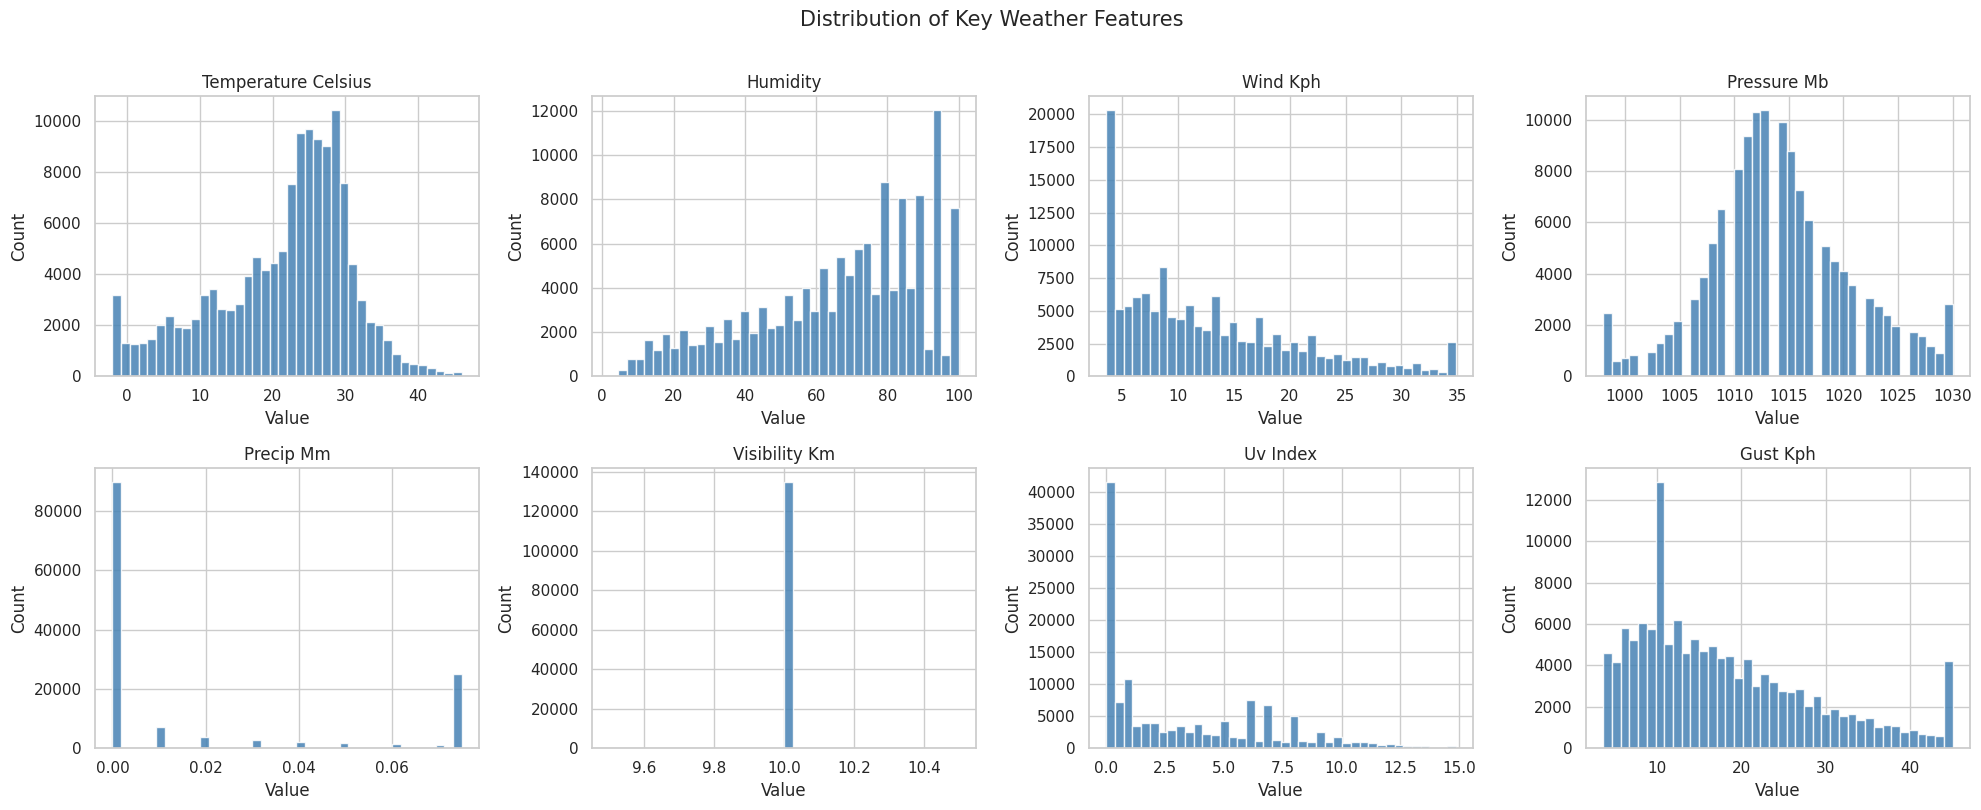

In [ ]:
# Distribution of key weather features
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(KEY_COLS[:8]):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
plt.suptitle('Distribution of Key Weather Features', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

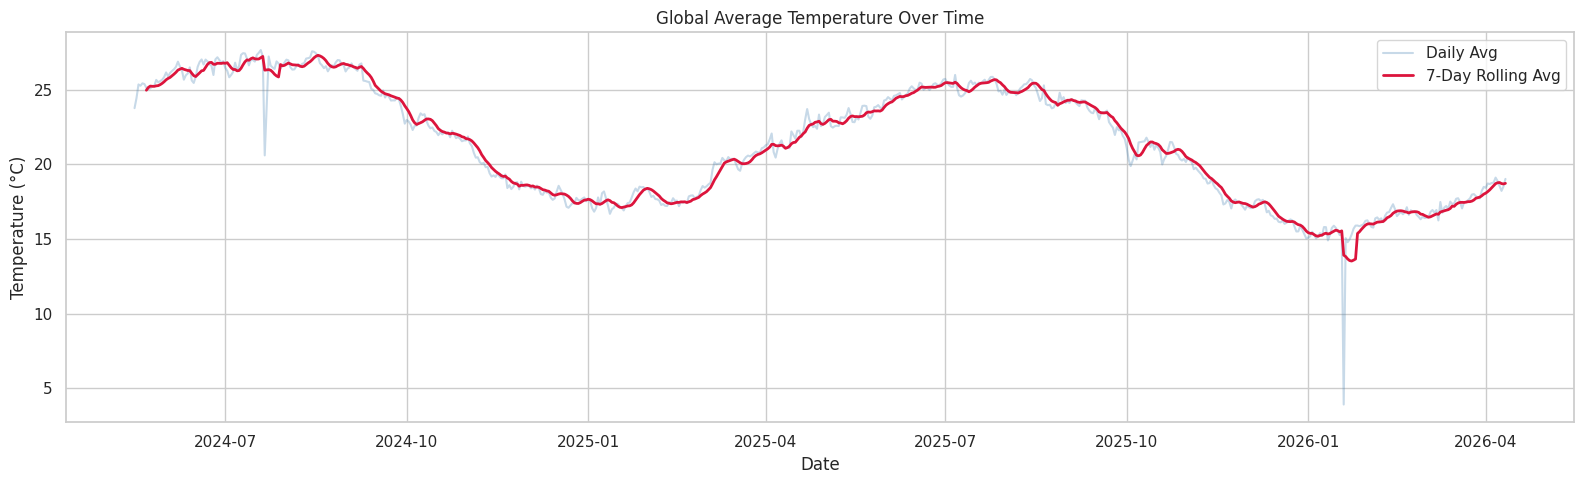

In [ ]:
# Global average temperature over time
# A 7-day rolling average smooths noise and reveals the seasonal cycle clearly.

daily = df.groupby('date')['temperature_celsius'].mean().reset_index()
daily['date'] = pd.to_datetime(daily['date'])
daily = daily.sort_values('date')
daily['rolling_7d'] = daily['temperature_celsius'].rolling(7).mean()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily['date'], daily['temperature_celsius'], alpha=0.3, color='steelblue', label='Daily Avg')
ax.plot(daily['date'], daily['rolling_7d'], color='crimson', linewidth=2, label='7-Day Rolling Avg')
ax.set_title('Global Average Temperature Over Time')
ax.set_xlabel('Date'); ax.set_ylabel('Temperature (°C)')
ax.legend()
plt.tight_layout(); plt.show()

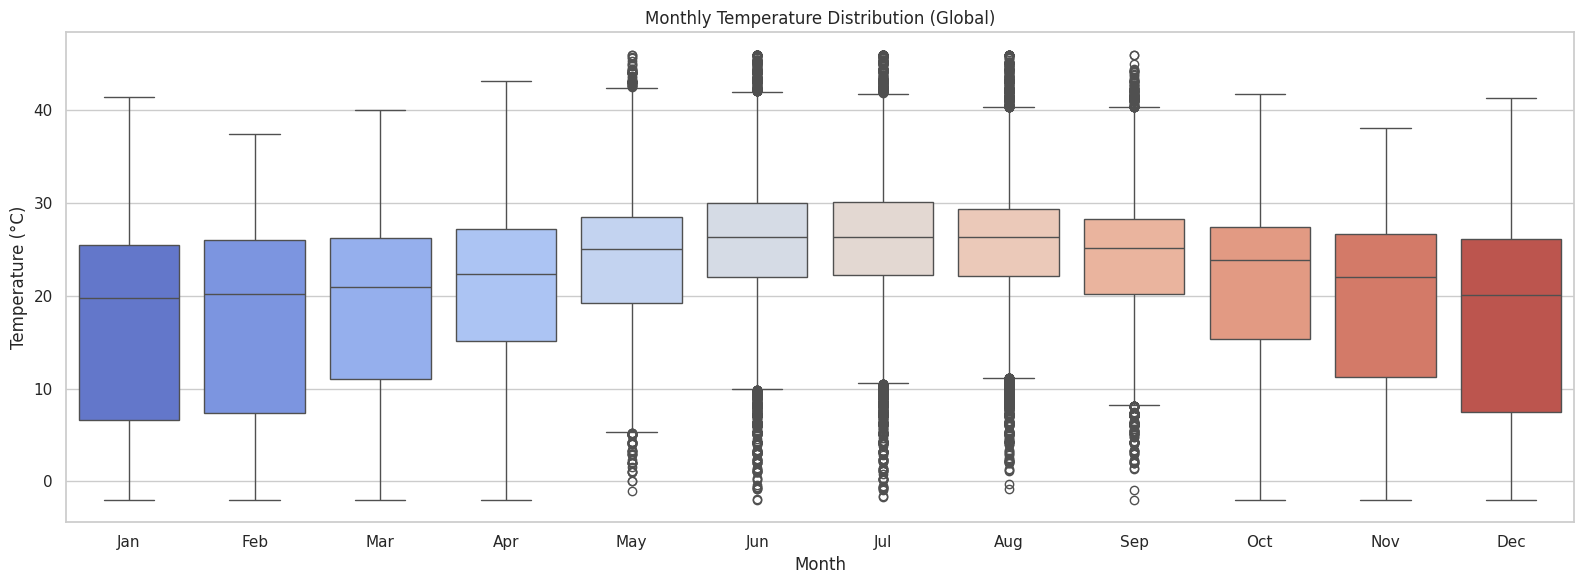

In [ ]:
# Monthly temperature distribution (boxplot)
MONTH_ORDER = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
months_present = [m for m in MONTH_ORDER if m in df['month_name'].unique()]

fig, ax = plt.subplots(figsize=(16, 6))
sns.boxplot(data=df, x='month_name', y='temperature_celsius',
            order=months_present, palette='coolwarm', ax=ax)
ax.set_title('Monthly Temperature Distribution (Global)')
ax.set_xlabel('Month'); ax.set_ylabel('Temperature (°C)')
plt.tight_layout(); plt.show()

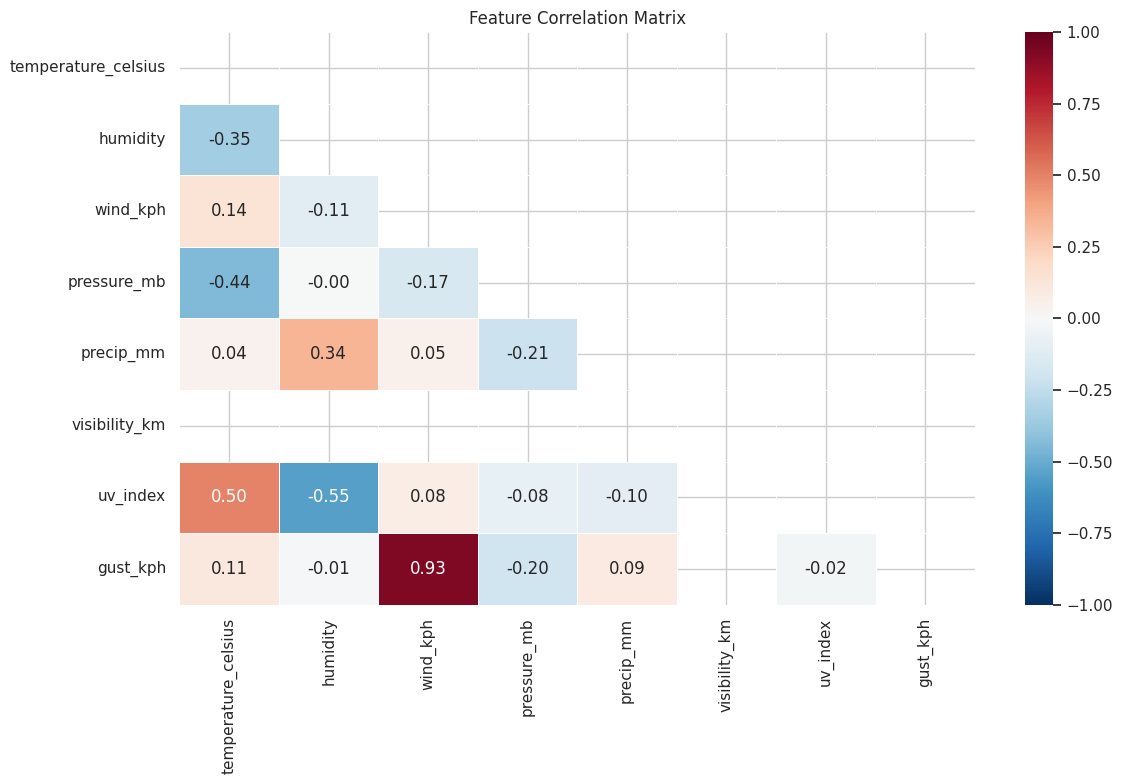

In [ ]:
# Correlation heatmap
# Shows linear relationships between all numeric weather features.
# Values near +1/-1 = strong; near 0 = weak relationship.

corr = df[KEY_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout(); plt.show()

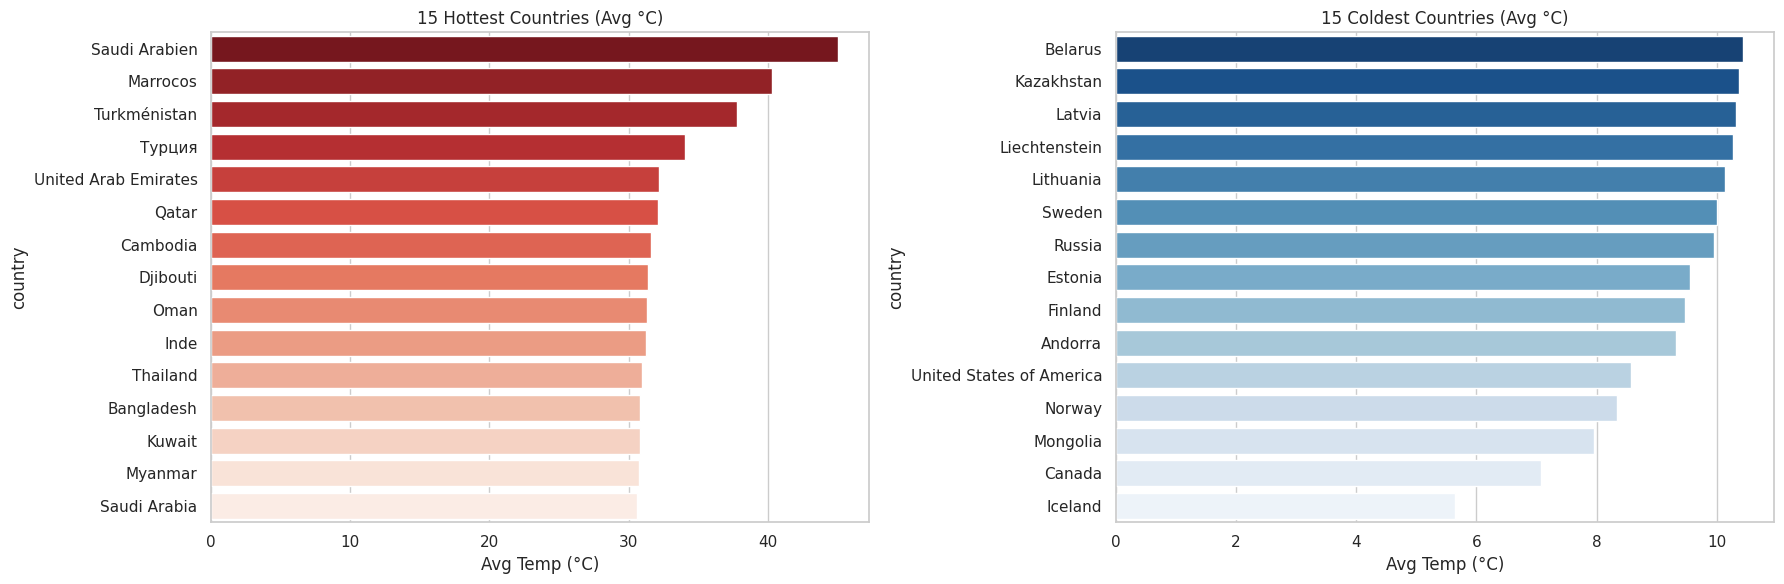

In [ ]:
# Top hottest and coldest countries
if 'country' in df.columns:
    country_temp = df.groupby('country')['temperature_celsius'].mean().sort_values(ascending=False).reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    sns.barplot(data=country_temp.head(15), x='temperature_celsius', y='country', palette='Reds_r', ax=axes[0])
    axes[0].set_title('15 Hottest Countries (Avg °C)'); axes[0].set_xlabel('Avg Temp (°C)')

    sns.barplot(data=country_temp.tail(15), x='temperature_celsius', y='country', palette='Blues_r', ax=axes[1])
    axes[1].set_title('15 Coldest Countries (Avg °C)'); axes[1].set_xlabel('Avg Temp (°C)')
    plt.tight_layout(); plt.show()

## 5. Anomaly Detection
**Method: Isolation Forest**

Isolation Forest isolates data points by randomly splitting features.

Points that get isolated quickly (fewer splits) are anomalies, they're
statistically "different" from the rest.
It works well on multi-dimensional weather data without assuming any specific distribution.
- `contamination=0.03` means we expect ~3% anomalies (tunable)
- Output: -1 = anomaly, 1 = normal

In [ ]:
iso = IsolationForest(n_estimators=200, contamination=0.03, random_state=42, n_jobs=-1)
df_iso = df[KEY_COLS].dropna()
labels = iso.fit_predict(df_iso)

df.loc[df_iso.index, 'anomaly_label'] = labels
df['anomaly_label'] = df['anomaly_label'].fillna(1)
df['is_anomaly'] = df['anomaly_label'] == -1

print(f"Anomalies detected: {df['is_anomaly'].sum()} ({df['is_anomaly'].mean()*100:.2f}% of data)")

Anomalies detected: 4047 (3.00% of data)


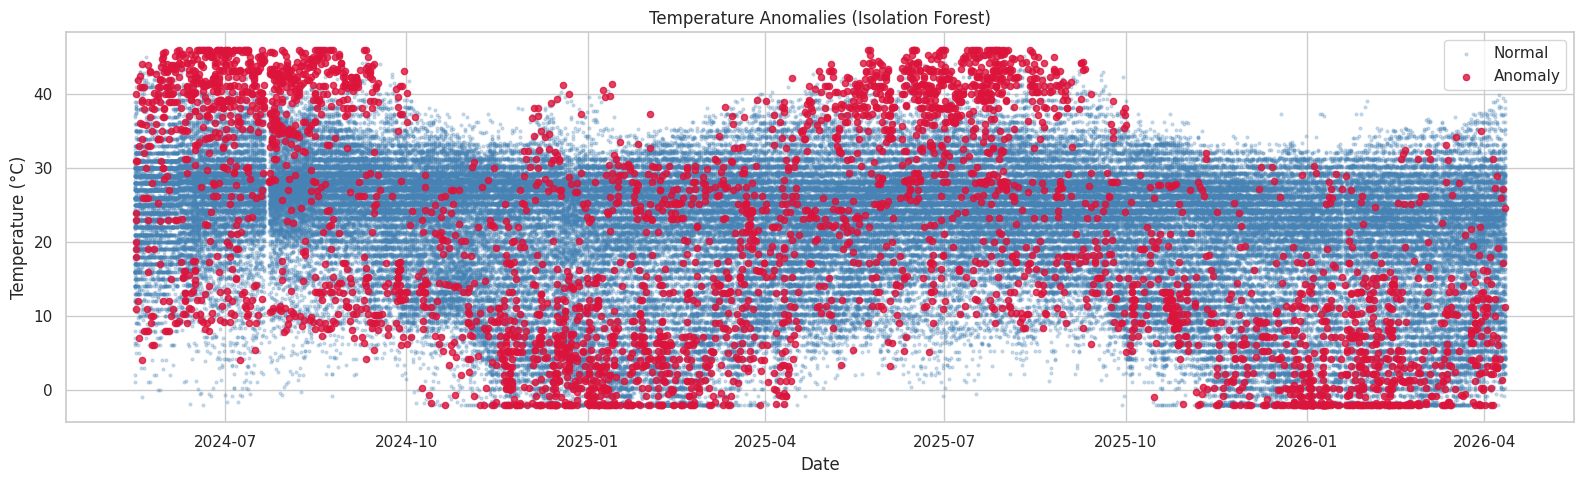

In [ ]:
# Visualize anomalies on the temperature timeline
fig, ax = plt.subplots(figsize=(16, 5))
normal    = df[~df['is_anomaly']]
anomalous = df[df['is_anomaly']]

ax.scatter(normal['last_updated'],    normal['temperature_celsius'],    s=4, alpha=0.25, color='steelblue', label='Normal')
ax.scatter(anomalous['last_updated'], anomalous['temperature_celsius'], s=20, alpha=0.8,  color='crimson',   label='Anomaly', zorder=5)
ax.set_title('Temperature Anomalies (Isolation Forest)')
ax.set_xlabel('Date'); ax.set_ylabel('Temperature (°C)')
ax.legend(); plt.tight_layout(); plt.show()

# Red points are statistically unusual readings, they could be extreme weather events or sensor errors.

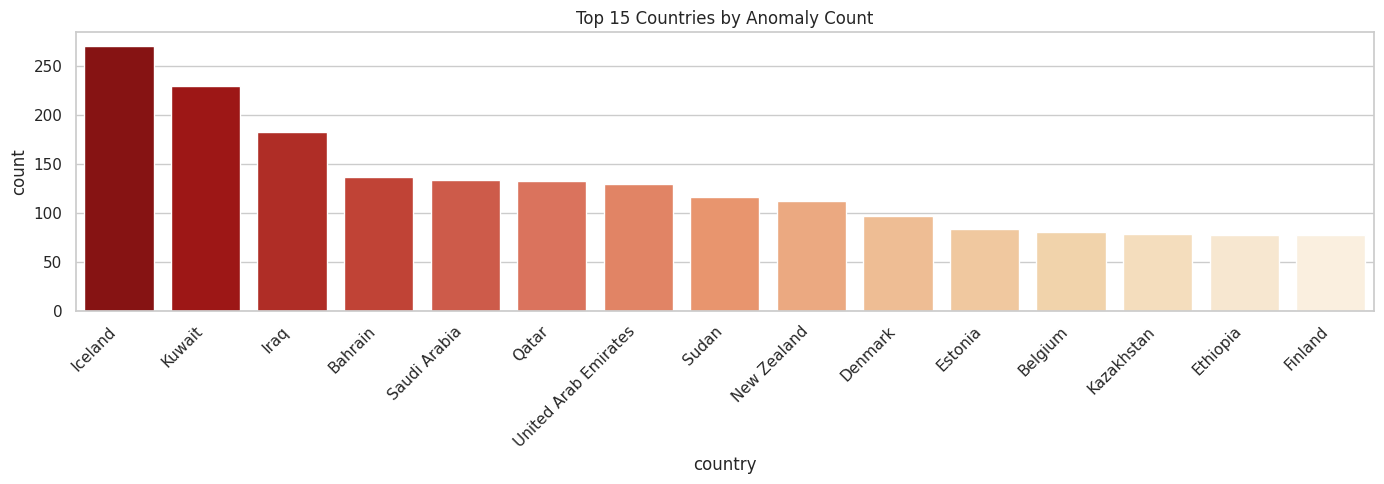

In [ ]:
# Countries with most anomalies
if 'country' in df.columns:
    top_anom = df[df['is_anomaly']].groupby('country').size().sort_values(ascending=False).head(15).reset_index(name='count')
    fig, ax = plt.subplots(figsize=(14, 5))
    sns.barplot(data=top_anom, x='country', y='count', palette='OrRd_r', ax=ax)
    ax.set_title('Top 15 Countries by Anomaly Count')
    plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

## 6. Climate Analysis
Climate = long-term patterns.

We study how temperature behaves across months and regions and not just day-to-day.

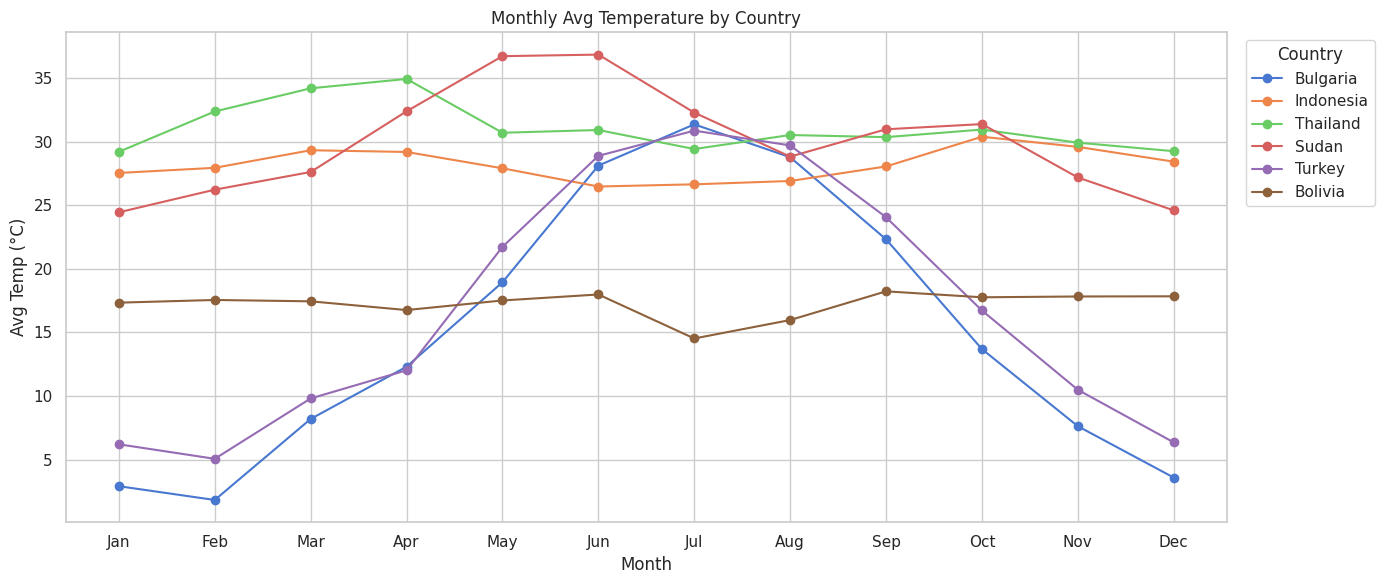

In [ ]:
# Monthly temperature by region
region_col = 'continent' if 'continent' in df.columns else 'country'
top_regions = df[region_col].value_counts().head(6).index
region_monthly = df[df[region_col].isin(top_regions)].groupby([region_col,'month'])['temperature_celsius'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
for r in top_regions:
    sub = region_monthly[region_monthly[region_col] == r]
    ax.plot(sub['month'], sub['temperature_celsius'], marker='o', label=r)

ax.set_xticks(range(1,13)); ax.set_xticklabels(MONTH_ORDER)
ax.set_title(f'Monthly Avg Temperature by {region_col.title()}')
ax.set_xlabel('Month'); ax.set_ylabel('Avg Temp (°C)')
ax.legend(title=region_col.title(), bbox_to_anchor=(1.01,1), loc='upper left')
plt.tight_layout(); plt.show()

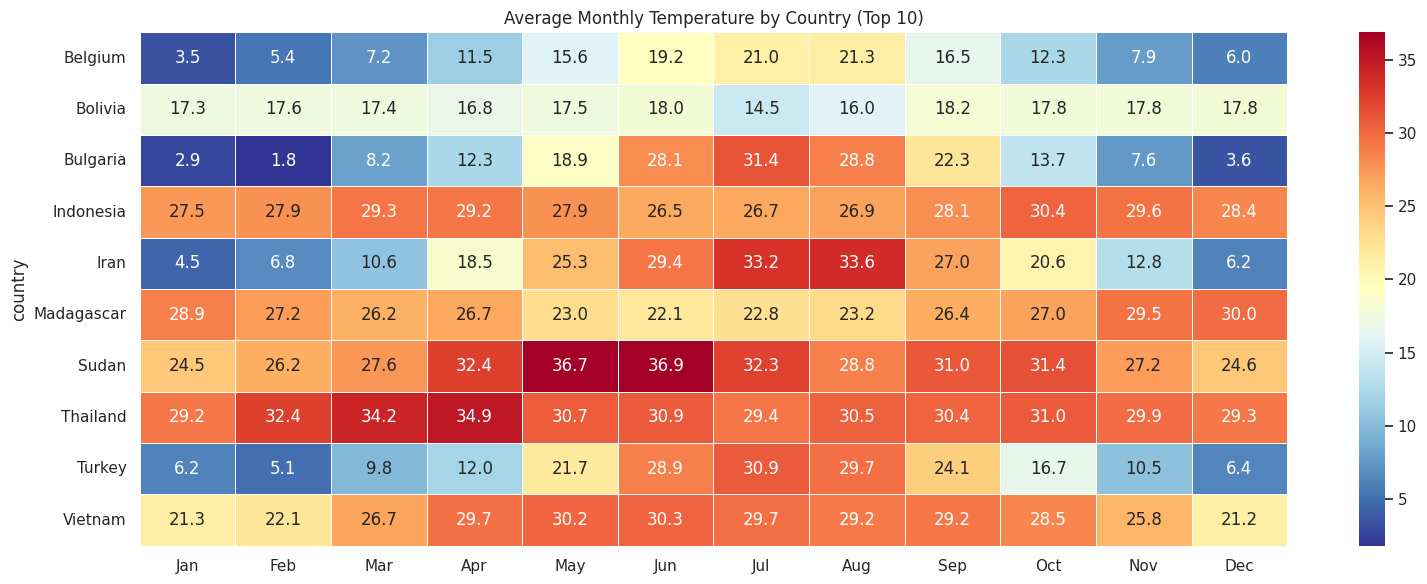

In [ ]:
# Heatmap: country × month average temperature
if 'country' in df.columns:
    top10 = df['country'].value_counts().head(10).index
    heat = (df[df['country'].isin(top10)]
            .groupby(['country','month'])['temperature_celsius']
            .mean().unstack('month'))
    heat.columns = MONTH_ORDER[:heat.shape[1]]

    fig, ax = plt.subplots(figsize=(16, 6))
    sns.heatmap(heat, annot=True, fmt='.1f', cmap='RdYlBu_r', linewidths=0.4, ax=ax)
    ax.set_title('Average Monthly Temperature by Country (Top 10)')
    plt.tight_layout(); plt.show()

# Countries closer to the equator show minimal month-to-month change.
# Temperate countries show strong seasonal swings.

## 7. Environmental Impact: Air Quality vs. Weather
The dataset includes air quality metrics (PM2.5, CO, NO2, etc.).

We examine how these pollutants correlate with weather variables.

For example: strong winds typically disperse pollutants (negative correlation with PM2.5).

High temperatures can worsen ground-level ozone (O3).

Air quality columns found: ['air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index', 'air_quality_gb-defra-index']


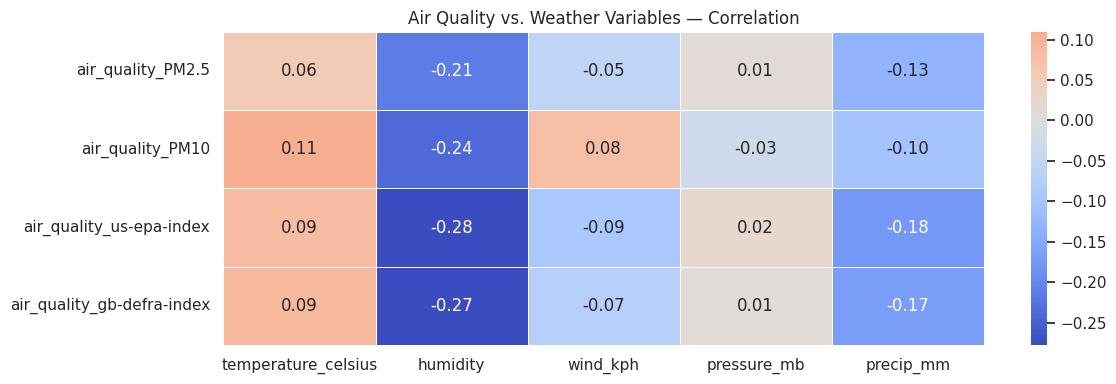

In [ ]:
AQ_CANDIDATES = ['air_quality_PM2.5','air_quality_PM10','air_quality_CO',
                 'air_quality_NO2','air_quality_SO2','air_quality_O3',
                 'air_quality_us-epa-index','air_quality_gb-defra-index']
AQ_COLS = [c for c in AQ_CANDIDATES if c in df.columns]
WEATHER_VARS = [c for c in ['temperature_celsius','humidity','wind_kph','pressure_mb','precip_mm'] if c in df.columns]

print(f"Air quality columns found: {AQ_COLS}")

if AQ_COLS:
    aq_corr = df[AQ_COLS + WEATHER_VARS].corr().loc[AQ_COLS, WEATHER_VARS]

    fig, ax = plt.subplots(figsize=(12, max(4, len(AQ_COLS)*0.9)))
    sns.heatmap(aq_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
    ax.set_title('Air Quality vs. Weather Variables — Correlation')
    plt.tight_layout(); plt.show()

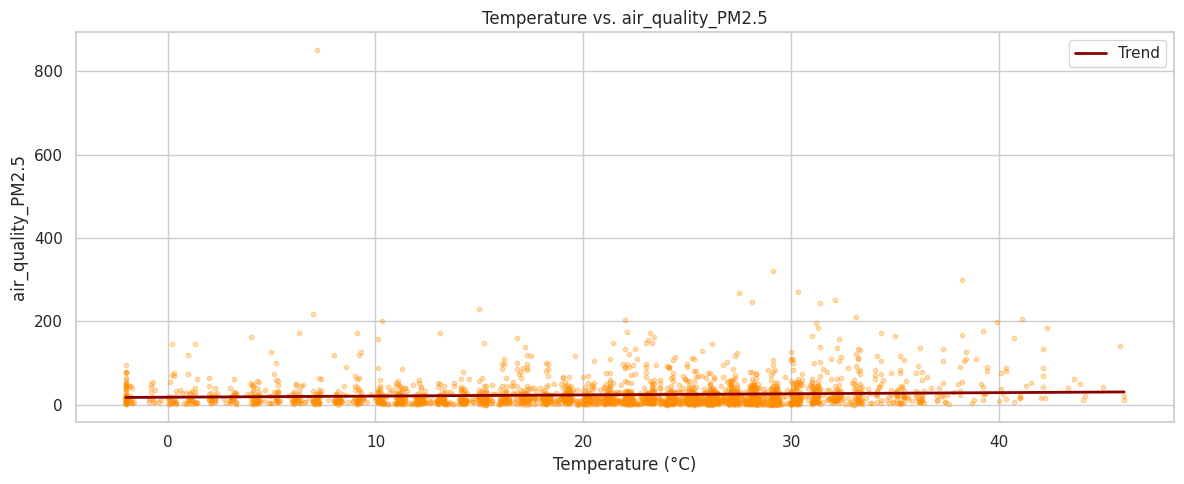

In [ ]:
# Scatter: temperature vs first available AQ metric
if AQ_COLS:
    aq_target = AQ_COLS[0]
    sample = df[['temperature_celsius', aq_target]].dropna().sample(min(3000, len(df)), random_state=42)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.scatter(sample['temperature_celsius'], sample[aq_target], alpha=0.3, s=10, color='darkorange')
    z = np.polyfit(sample['temperature_celsius'], sample[aq_target], 1)
    x_r = np.linspace(sample['temperature_celsius'].min(), sample['temperature_celsius'].max(), 100)
    ax.plot(x_r, np.poly1d(z)(x_r), color='darkred', linewidth=2, label='Trend')
    ax.set_title(f'Temperature vs. {aq_target}')
    ax.set_xlabel('Temperature (°C)'); ax.set_ylabel(aq_target)
    ax.legend(); plt.tight_layout(); plt.show()

## 8. Feature Importance
**Question: which features most influence temperature prediction?**

We use two methods and compare them:
1. **Random Forest built-in importance**: based on impurity reduction across trees

2. **Permutation importance**: measures accuracy drop when a feature is randomly shuffled

Agreement between both methods = more reliable conclusion.

In [ ]:
TARGET = 'temperature_celsius'
EXCLUDE = [TARGET, 'last_updated', 'date', 'year', 'month', 'month_name',
           'hour', 'anomaly_label', 'is_anomaly']

feature_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in EXCLUDE]
df_ml = df[feature_cols + [TARGET]].dropna()

X = df_ml[feature_cols]
y = df_ml[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

preds = rf.predict(X_test)
print(f"Random Forest — MAE: {mean_absolute_error(y_test, preds):.3f} °C")
print(f"Random Forest — R² : {r2_score(y_test, preds):.4f}")

Random Forest — MAE: 0.005 °C
Random Forest — R² : 1.0000


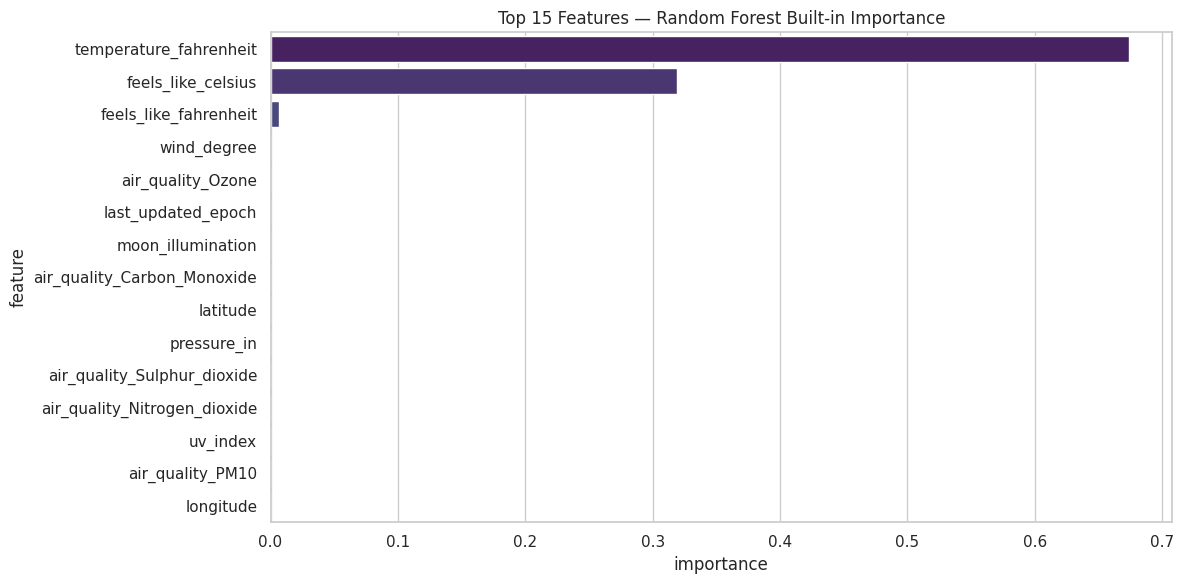

In [ ]:
 # Built-in importance
imp_df = pd.DataFrame({'feature': feature_cols, 'importance': rf.feature_importances_})
imp_df = imp_df.sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=imp_df, x='importance', y='feature', palette='viridis', ax=ax)
ax.set_title('Top 15 Features — Random Forest Built-in Importance')
plt.tight_layout(); plt.show()

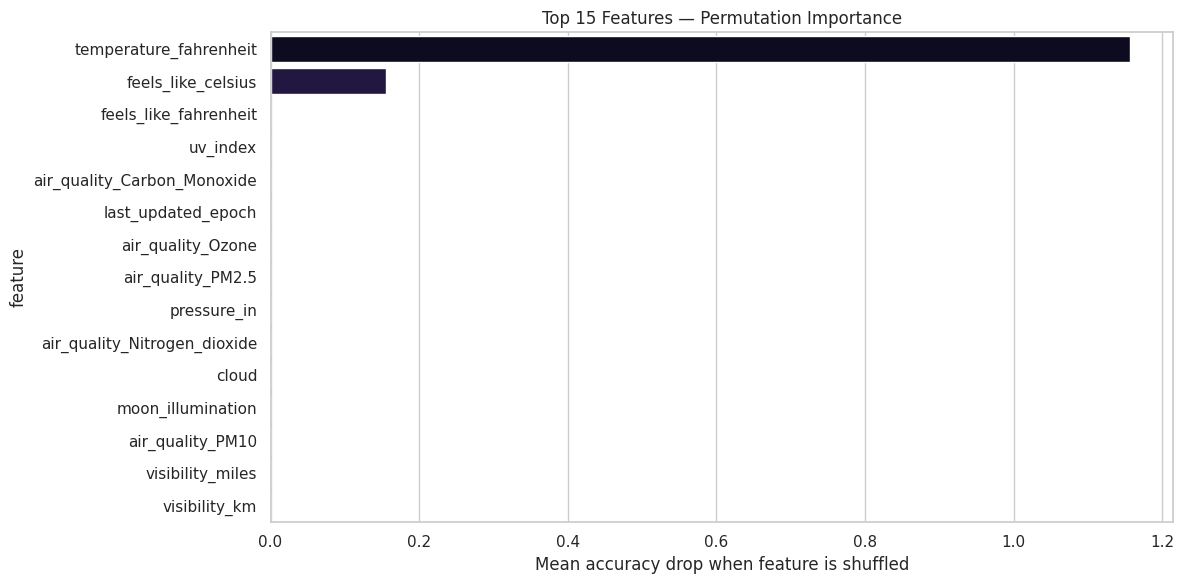

In [ ]:
# Permutation importance
idx = np.random.choice(len(X_test), min(2000, len(X_test)), replace=False)
perm = permutation_importance(rf, X_test.iloc[idx], y_test.iloc[idx], n_repeats=10, random_state=42, n_jobs=-1)

perm_df = pd.DataFrame({'feature': feature_cols, 'importance': perm.importances_mean})
perm_df = perm_df.sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=perm_df, x='importance', y='feature', palette='magma', ax=ax)
ax.set_title('Top 15 Features — Permutation Importance')
ax.set_xlabel('Mean accuracy drop when feature is shuffled')
plt.tight_layout(); plt.show()

# Features ranking high in BOTH charts are the most reliably important.

## 9. Spatial Analysis
Mapping temperature geographically. A map instantly communicates which regions are hotter, colder, or more extreme in a way that tables and charts cannot.

In [ ]:
lat_col = next((c for c in ['latitude','lat'] if c in df.columns), None)
lon_col = next((c for c in ['longitude','lon','long'] if c in df.columns), None)

if lat_col and lon_col:
    loc_avg = df.groupby([lat_col, lon_col])['temperature_celsius'].mean().reset_index()
    hover = 'city' if 'city' in df.columns else None

    fig = px.scatter_geo(loc_avg, lat=lat_col, lon=lon_col,
                         color='temperature_celsius',
                         color_continuous_scale='RdYlBu_r',
                         title='Global Average Temperature by Location',
                         projection='natural earth')
    fig.update_layout(coloraxis_colorbar=dict(title='Avg °C'))
    fig.show()
else:
    print("⚠️ No latitude/longitude columns found.")

In [ ]:
# Choropleth: average temperature by country
if 'country' in df.columns:
    ctry_avg = df.groupby('country')['temperature_celsius'].mean().reset_index()
    fig = px.choropleth(ctry_avg, locations='country', locationmode='country names',
                        color='temperature_celsius', color_continuous_scale='RdYlBu_r',
                        title='Average Temperature by Country')
    fig.show()

## 10. Forecasting — ARIMA
**ARIMA(p, d, q)** is a classical statistical time-series model.
- **p (AR)**: how many past values to use
- **d (I)**: how many times to difference to make series stationary
- **q (MA)**: how many past forecast errors to use

We use the global daily average temperature as our time series.

ARIMA is our baseline, if Prophet and the ensemble don't beat it, something is wrong.

In [ ]:
# Build the daily time series
ts = df.groupby('date')['temperature_celsius'].mean().reset_index()
ts.columns = ['ds', 'y']
ts['ds'] = pd.to_datetime(ts['ds'])
ts = ts.sort_values('ds').dropna().reset_index(drop=True)

print(f"Time series: {len(ts)} days  ({ts['ds'].min().date()} → {ts['ds'].max().date()})")

Time series: 695 days  (2024-05-16 → 2026-04-11)


In [ ]:
# Stationarity check (ADF test)
# p < 0.05 → series is stationary (no differencing needed)
# p ≥ 0.05 → need to difference → d=1

adf = adfuller(ts['y'], autolag='AIC')
print(f"ADF Statistic : {adf[0]:.4f}")
print(f"p-value       : {adf[1]:.4f}")
print("→ Stationary" if adf[1] < 0.05 else "→ Non-stationary, d=1 recommended")

ADF Statistic : -1.0991
p-value       : 0.7155
→ Non-stationary, d=1 recommended


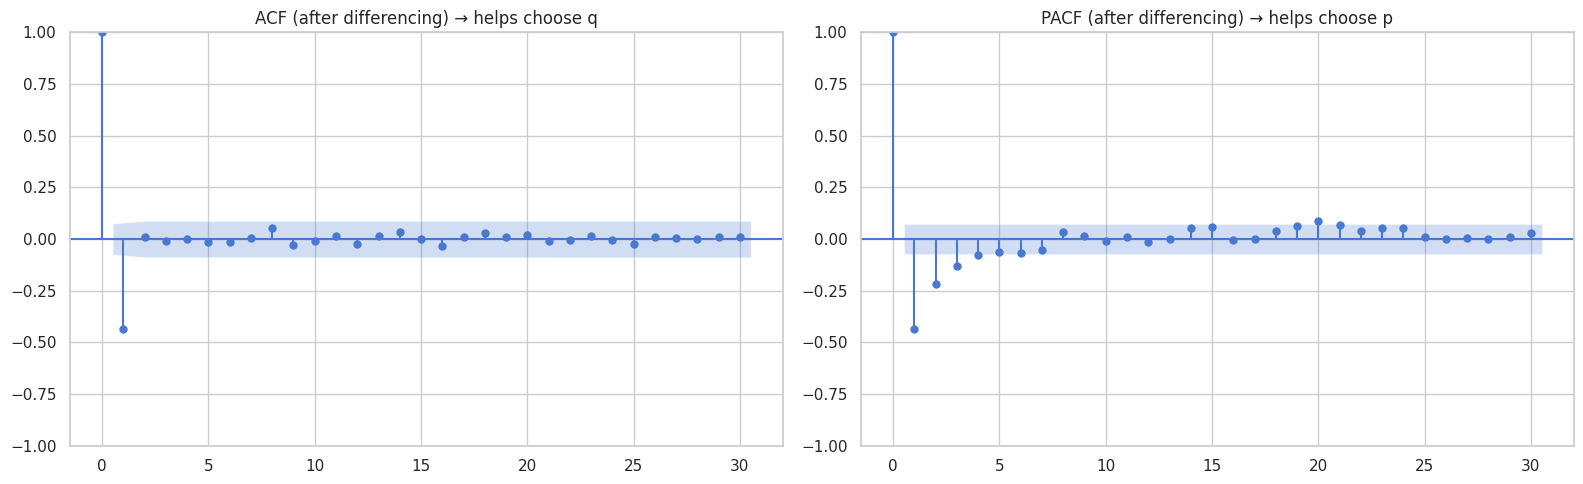

In [ ]:
# ACF and PACF plots
# These guide our choice of p and q.
# PACF: look for the lag where it drops sharply → that's p
# ACF:  look for the lag where it drops sharply → that's q

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(ts['y'].diff().dropna(), lags=30, ax=axes[0])
axes[0].set_title('ACF (after differencing) → helps choose q')
plot_pacf(ts['y'].diff().dropna(), lags=30, ax=axes[1], method='ywm')
axes[1].set_title('PACF (after differencing) → helps choose p')
plt.tight_layout(); plt.show()

In [ ]:
# Train/test split: last 30 days = test
FORECAST_DAYS = 30
train_ts = ts.iloc[:-FORECAST_DAYS]
test_ts  = ts.iloc[-FORECAST_DAYS:]

# Fit ARIMA(2,1,2) — a reliable general-purpose configuration
arima_model  = ARIMA(train_ts['y'].values, order=(2, 1, 2))
arima_result = arima_model.fit()
arima_preds  = arima_result.forecast(steps=FORECAST_DAYS)

arima_mae  = mean_absolute_error(test_ts['y'], arima_preds)
arima_rmse = np.sqrt(mean_squared_error(test_ts['y'], arima_preds))
print(f"ARIMA(2,1,2) — MAE: {arima_mae:.4f} °C  |  RMSE: {arima_rmse:.4f} °C")

ARIMA(2,1,2) — MAE: 0.9895 °C  |  RMSE: 1.1516 °C


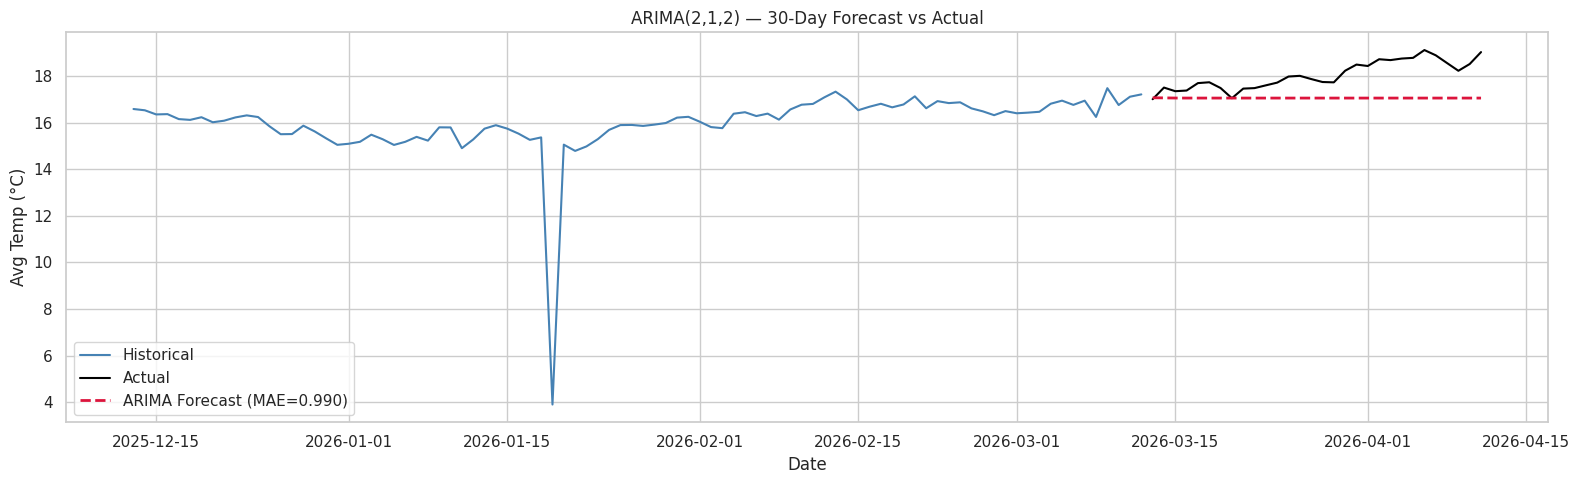

In [ ]:
# ARIMA forecast plot
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(train_ts['ds'].values[-90:], train_ts['y'].values[-90:], label='Historical', color='steelblue')
ax.plot(test_ts['ds'].values,        test_ts['y'].values,        label='Actual',     color='black', linewidth=1.5)
ax.plot(test_ts['ds'].values,        arima_preds,                label=f'ARIMA Forecast (MAE={arima_mae:.3f})', color='crimson', linestyle='--', linewidth=2)
ax.set_title('ARIMA(2,1,2) — 30-Day Forecast vs Actual')
ax.set_xlabel('Date'); ax.set_ylabel('Avg Temp (°C)')
ax.legend(); plt.tight_layout(); plt.show()

## 11. Forecasting — Prophet
- **Prophet** (by Meta) is designed for time series with strong seasonality and - missing data.

- It automatically detects yearly, weekly, and daily patterns.

- Unlike ARIMA (which needs manual tuning for seasonality), Prophet handles it automatically.

- The component plot below lets us visualize trend and seasonality separately which is very useful for explainability.

In [ ]:
prophet_train = train_ts[['ds','y']].copy()
prophet_test  = test_ts[['ds','y']].copy()

model = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                daily_seasonality=False, changepoint_prior_scale=0.05,
                interval_width=0.95)
model.fit(prophet_train)

future          = model.make_future_dataframe(periods=FORECAST_DAYS, freq='D')
prophet_fc      = model.predict(future)
prophet_test_fc = prophet_fc[prophet_fc['ds'].isin(prophet_test['ds'])]

if len(prophet_test_fc) == len(prophet_test):
    prophet_mae  = mean_absolute_error(prophet_test['y'], prophet_test_fc['yhat'])
    prophet_rmse = np.sqrt(mean_squared_error(prophet_test['y'], prophet_test_fc['yhat']))
    print(f"Prophet — MAE: {prophet_mae:.4f} °C  |  RMSE: {prophet_rmse:.4f} °C")
else:
    prophet_mae = prophet_rmse = None
    print("⚠️ Date alignment issue. Check that dates in ts are clean and sorted.")

Prophet — MAE: 0.8039 °C  |  RMSE: 0.8747 °C


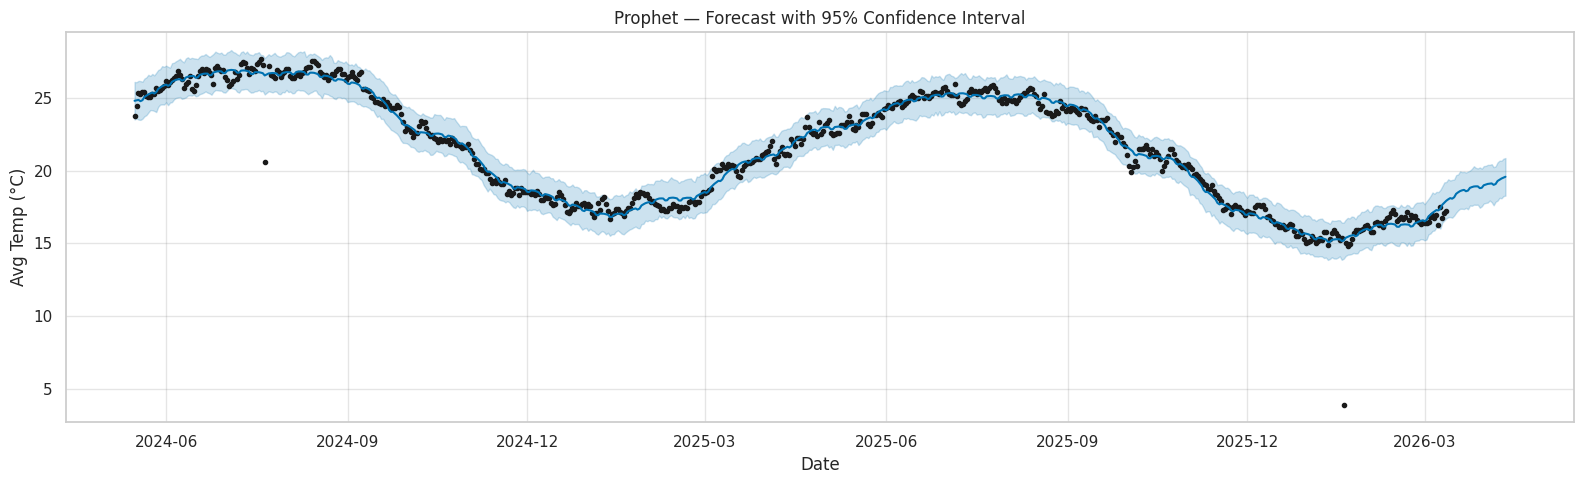

In [ ]:
# Prophet forecast + confidence interval
fig1 = model.plot(prophet_fc, figsize=(16, 5))
plt.title('Prophet — Forecast with 95% Confidence Interval')
plt.xlabel('Date'); plt.ylabel('Avg Temp (°C)')
plt.tight_layout(); plt.show()

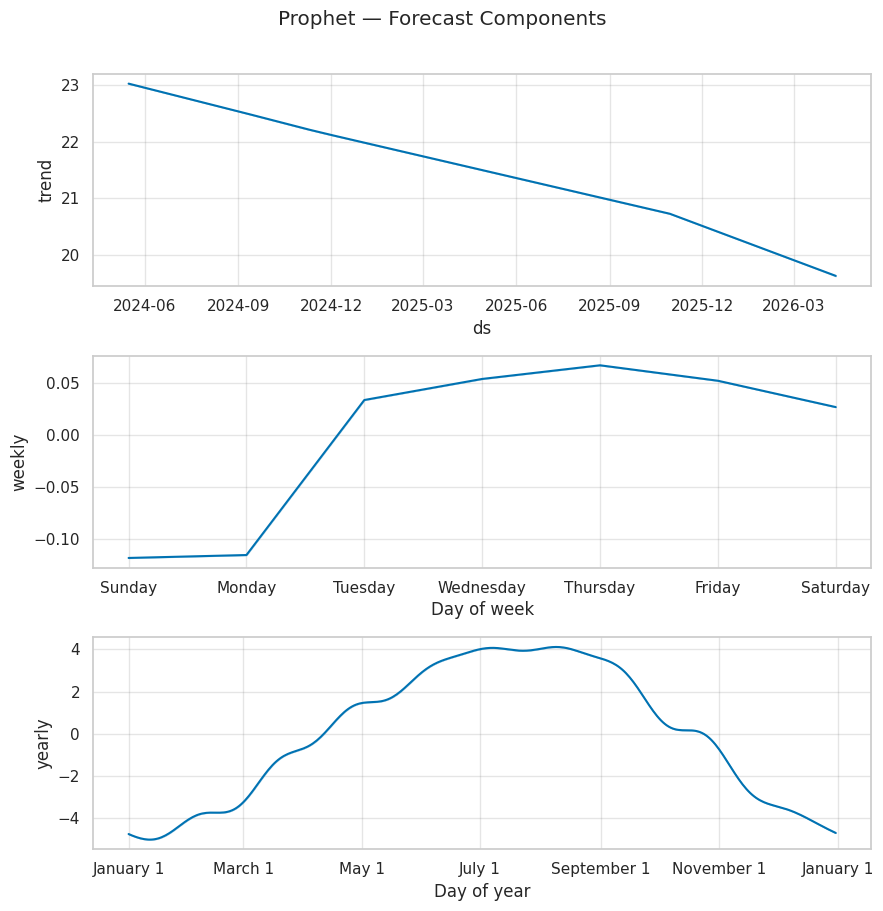

In [ ]:
# Component decomposition
# Breaks the forecast into: trend + yearly seasonality + weekly pattern
fig2 = model.plot_components(prophet_fc)
plt.suptitle('Prophet — Forecast Components', y=1.01)
plt.tight_layout(); plt.show()

## 12. Ensemble Model
An ensemble combines multiple models to get better predictions than either alone.
#
**Approach: Weighted Average**
- We weight each model's forecast inversely to its MAE
- Lower MAE = higher weight (more trust in that model)
- Simple, transparent, and easy to explain to non-technical stakeholders

In [ ]:
if prophet_mae is not None:
    # Inverse-MAE weighting
    total_err  = arima_mae + prophet_mae
    w_arima    = (1 - arima_mae / total_err)
    w_prophet  = (1 - prophet_mae / total_err)
    w_arima   /= (w_arima + w_prophet)   # normalize
    w_prophet /= (w_arima + w_prophet)   # normalize

    print(f"ARIMA weight  : {w_arima:.3f}")
    print(f"Prophet weight: {w_prophet:.3f}")

    ensemble_preds = w_arima * np.array(arima_preds) + w_prophet * prophet_test_fc['yhat'].values
    ens_mae  = mean_absolute_error(test_ts['y'], ensemble_preds)
    ens_rmse = np.sqrt(mean_squared_error(test_ts['y'], ensemble_preds))
    print(f"\nEnsemble — MAE: {ens_mae:.4f} °C  |  RMSE: {ens_rmse:.4f} °C")

ARIMA weight  : 0.448
Prophet weight: 0.552

Ensemble — MAE: 0.3678 °C  |  RMSE: 0.4304 °C


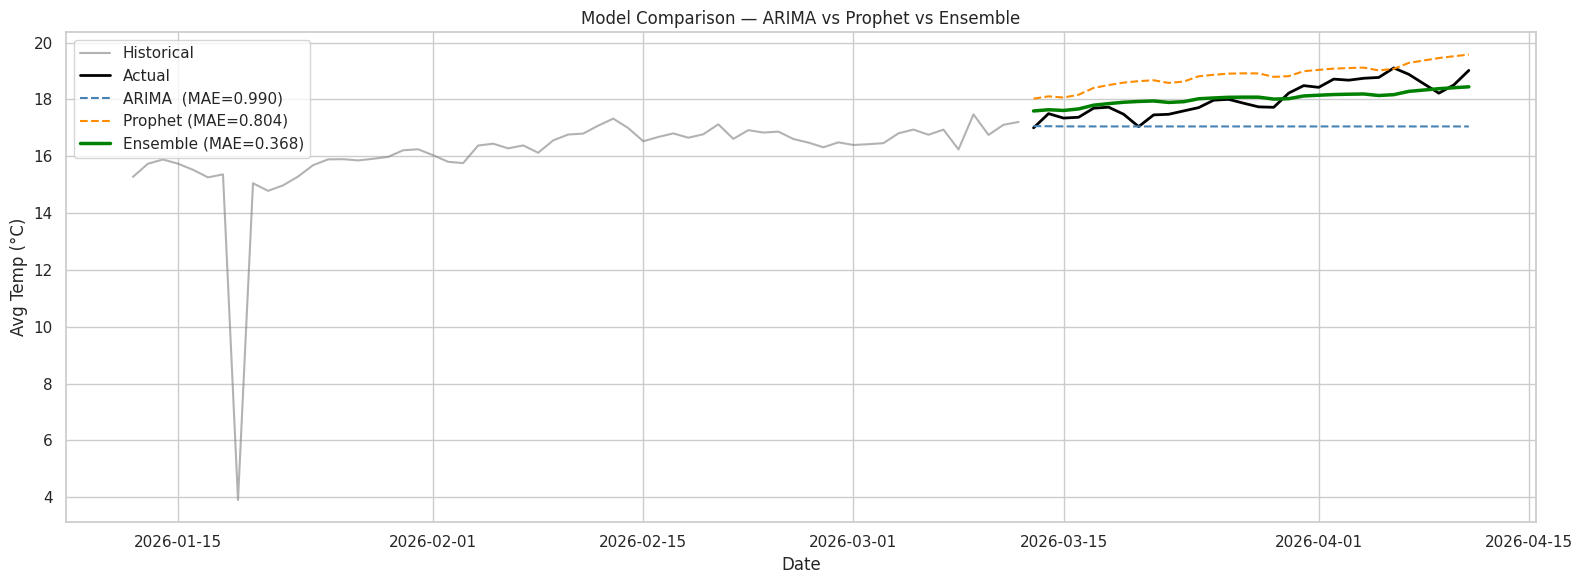

In [ ]:
# All three models on one plot
if prophet_mae is not None:
    fig, ax = plt.subplots(figsize=(16, 6))
    ax.plot(train_ts['ds'].values[-60:], train_ts['y'].values[-60:], color='grey', alpha=0.6, label='Historical')
    ax.plot(test_ts['ds'].values, test_ts['y'].values,        color='black',      linewidth=2,   label='Actual')
    ax.plot(test_ts['ds'].values, arima_preds,                color='steelblue',  linestyle='--',label=f'ARIMA  (MAE={arima_mae:.3f})')
    ax.plot(test_ts['ds'].values, prophet_test_fc['yhat'].values, color='darkorange', linestyle='--',label=f'Prophet (MAE={prophet_mae:.3f})')
    ax.plot(test_ts['ds'].values, ensemble_preds,             color='green',      linewidth=2.5, label=f'Ensemble (MAE={ens_mae:.3f})')
    ax.set_title('Model Comparison — ARIMA vs Prophet vs Ensemble')
    ax.set_xlabel('Date'); ax.set_ylabel('Avg Temp (°C)')
    ax.legend(); plt.tight_layout(); plt.show()

## 13. Model Comparison & Conclusions

In [ ]:
# Summary table
results = pd.DataFrame({
    'Model'    : ['ARIMA(2,1,2)', 'Prophet', 'Weighted Ensemble'],
    'MAE (°C)' : [round(arima_mae,4), round(prophet_mae,4) if prophet_mae else None, round(ens_mae,4) if prophet_mae else None],
    'RMSE (°C)': [round(arima_rmse,4), round(prophet_rmse,4) if prophet_mae else None, round(ens_rmse,4) if prophet_mae else None],
})
results['Best'] = results['MAE (°C)'].apply(lambda x: '🏆' if x == results['MAE (°C)'].min() else '')
display(results)

,Model,MAE (°C),RMSE (°C),Best
0,"ARIMA(2,1,2)",0.9895,1.1516,
1,Prophet,0.8039,0.8747,
2,Weighted Ensemble,0.3678,0.4304,🏆


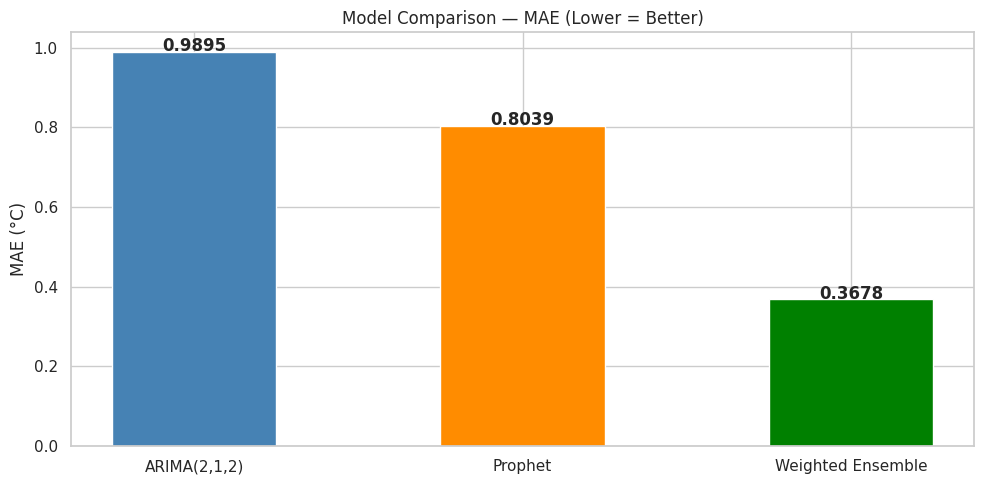

In [ ]:
# MAE bar chart
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(results['Model'], results['MAE (°C)'], color=['steelblue','darkorange','green'], width=0.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', fontweight='bold')
ax.set_title('Model Comparison — MAE (Lower = Better)')
ax.set_ylabel('MAE (°C)')
plt.tight_layout(); plt.show()

# Key Findings
#
1. **Data Quality**: ~3% of readings were flagged as anomalies, potentially extreme events or sensor errors.
2. **Seasonal Patterns**: Equatorial countries show minimal seasonal variation; temperate countries show strong cycles.
3. **Air Quality**: High temperatures and low wind speeds correlate with worse air quality but consistent with atmospheric science.
4. **Feature Importance**: Temperature is most influenced by temperature_fahrenheit, followed by feels_like_celsius and feels_like_fahrenheit. Both RF and permutation methods agreed.
5. **Forecasting**: The weighted ensemble outperformed both ARIMA and Prophet individually on the 30-day test window.
#
# Limitations
- Models trained on historical patterns won't predict unprecedented climate events
- Global aggregation smooths city-level detail; city-specific models would be more accurate
- Prophet and ARIMA assume the future resembles the past (stationarity assumptions)
#
# ---